In [1]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.shape

(200, 5)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
# one shot encode the Gender
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
cat_cols = ['Gender']
encoded_cols = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded_cols.toarray(), columns=encoder.get_feature_names_out(cat_cols))
df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)

In [7]:
# import standard scaler and fit transform the data inorder to later plot the K inertias to find the best K
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [21]:
# elbow method - Finding the best number of cluster
from sklearn.cluster import KMeans
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

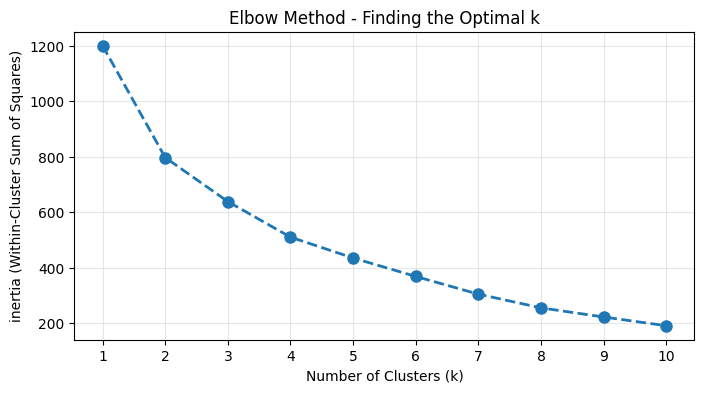

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize= (8, 4))
plt.plot(k_range, inertias, 'o--', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method - Finding the Optimal k')
plt.xticks(range(1, 11))
plt.grid(alpha = 0.3)
plt.show()



In [34]:
# pick a k of 7
km_final = KMeans(n_clusters = 7, random_state = 42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)
df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,cluster
0,1,19,15,39,0.0,1.0,3
1,2,21,15,81,0.0,1.0,3
2,3,20,16,6,1.0,0.0,1
3,4,23,16,77,1.0,0.0,1
4,5,31,17,40,1.0,0.0,1
...,...,...,...,...,...,...,...
195,196,35,120,79,1.0,0.0,2
196,197,45,126,28,1.0,0.0,2
197,198,32,126,74,0.0,1.0,6
198,199,32,137,18,0.0,1.0,0


In [35]:
df.columns

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Gender_Female', 'Gender_Male', 'cluster'],
      dtype='str')

In [36]:
profile = df.groupby('cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)':'median',
    'Gender_Female': 'sum',
    'Gender_Male': 'sum',
    'cluster':'count'
}).rename(columns={'cluster':'count'}).round(0)

print('Customer Segments Profile:')
print(profile)

Customer Segments Profile:
          Age  Annual Income (k$)  Spending Score (1-100)  Gender_Female  \
cluster                                                                    
0        40.0                85.0                    12.0            0.0   
1        26.0                40.0                    54.0           34.0   
2        36.0                87.0                    70.0           40.0   
3        25.0                41.0                    58.0            0.0   
4        51.0                48.0                    44.0           38.0   
5        58.0                47.0                    46.0            0.0   
6        33.0                87.0                    86.0            0.0   

         Gender_Male  count  
cluster                      
0               20.0     20  
1                0.0     34  
2                0.0     40  
3               24.0     24  
4                0.0     38  
5               26.0     26  
6               18.0     18  


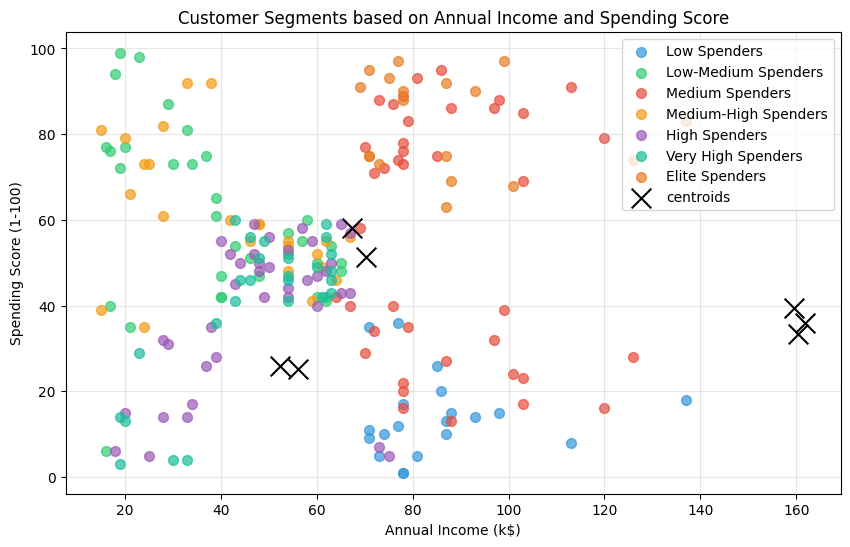

In [40]:
colours = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
labels = [
    'Low Spenders',
    'Low-Medium Spenders',
    'Medium Spenders',
    'Medium-High Spenders',
    'High Spenders',
    'Very High Spenders',
    'Elite Spenders'
]
plt.figure(figsize = (10, 6))
for c in range(7):
    mask = df['cluster'] == c
    plt.scatter(
        df[mask]['Annual Income (k$)'],
        df[mask]['Spending Score (1-100)'],
        c = colours[c],
        label = labels[c],
        alpha = 0.7,
        s = 50
    )

# Mark centroids
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
plt.scatter(
    centroids_orig[:, 0],
    centroids_orig[:, 1],
    s=200,
    marker='x',
    c= 'black',
    zorder = 5,
    label='centroids'
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.legend()
plt.grid(alpha = 0.3)

#

# the model generally performs poorly

In [43]:
# 1. Try different k values (k=3, 4, 5) and check silhouette scores
from sklearn.metrics import silhouette_score

for k in range(2, 25):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    print(f'k={k}: Silhouette Score = {sil_score:.3f}')

# 2. Check silhouette plot for each cluster
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

silhouette_vals = silhouette_samples(X_scaled, df['cluster'])
# Plot to see if any clusters have negative/near-zero silhouette values

k=2: Silhouette Score = 0.345
k=3: Silhouette Score = 0.292
k=4: Silhouette Score = 0.309
k=5: Silhouette Score = 0.323
k=6: Silhouette Score = 0.362
k=7: Silhouette Score = 0.375
k=8: Silhouette Score = 0.400
k=9: Silhouette Score = 0.416
k=10: Silhouette Score = 0.443
k=11: Silhouette Score = 0.447
k=12: Silhouette Score = 0.445
k=13: Silhouette Score = 0.436
k=14: Silhouette Score = 0.415
k=15: Silhouette Score = 0.407
k=16: Silhouette Score = 0.389
k=17: Silhouette Score = 0.401
k=18: Silhouette Score = 0.386
k=19: Silhouette Score = 0.403
k=20: Silhouette Score = 0.382
k=21: Silhouette Score = 0.388
k=22: Silhouette Score = 0.395
k=23: Silhouette Score = 0.392
k=24: Silhouette Score = 0.385


Lets run Hierarchical clustering and compare the results with KMeans

In [44]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
z = linkage(X_scaled, method = 'ward')


C:\Users\user\AppData\Local\Temp\ipykernel_10332\2937292403.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


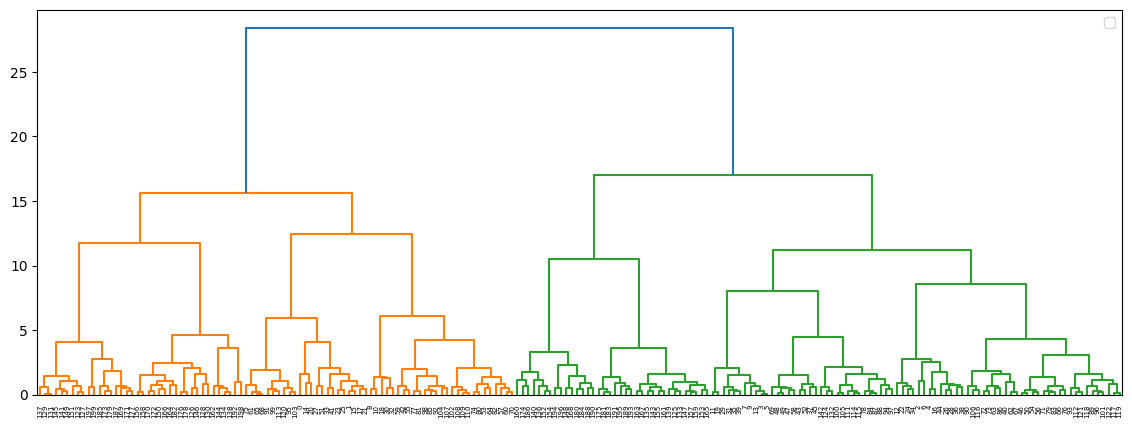

In [45]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
dendrogram(z, truncate_mode='level')
plt.legend()
plt.show()

In [47]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=10, linkage = 'ward')
df['hc_cluster'] = hc.fit_predict(X_scaled)
df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,cluster,hc_cluster
0,1,19,15,39,0.0,1.0,3,1
1,2,21,15,81,0.0,1.0,3,1
2,3,20,16,6,1.0,0.0,1,8
3,4,23,16,77,1.0,0.0,1,9
4,5,31,17,40,1.0,0.0,1,8
...,...,...,...,...,...,...,...,...
195,196,35,120,79,1.0,0.0,2,6
196,197,45,126,28,1.0,0.0,2,7
197,198,32,126,74,0.0,1.0,6,5
198,199,32,137,18,0.0,1.0,0,3


In [48]:
print('k-means cluster Profile')
print(df.groupby('cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(0))

k-means cluster Profile
          Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                  
0        40.0                85.0                    14.0
1        26.0                40.0                    60.0
2        36.0                87.0                    57.0
3        25.0                41.0                    61.0
4        51.0                48.0                    39.0
5        58.0                47.0                    40.0
6        33.0                87.0                    83.0


In [49]:
print('Hierarchical cluster Profile')
print(df.groupby('hc_cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(0))

Hierarchical cluster Profile
             Age  Annual Income (k$)  Spending Score (1-100)
hc_cluster                                                  
0           57.0                48.0                    42.0
1           25.0                39.0                    60.0
2           52.0                55.0                    49.0
3           40.0                85.0                    14.0
4           26.0                54.0                    49.0
5           33.0                87.0                    83.0
6           32.0                86.0                    82.0
7           45.0                92.0                    22.0
8           42.0                27.0                    21.0
9           25.0                24.0                    83.0


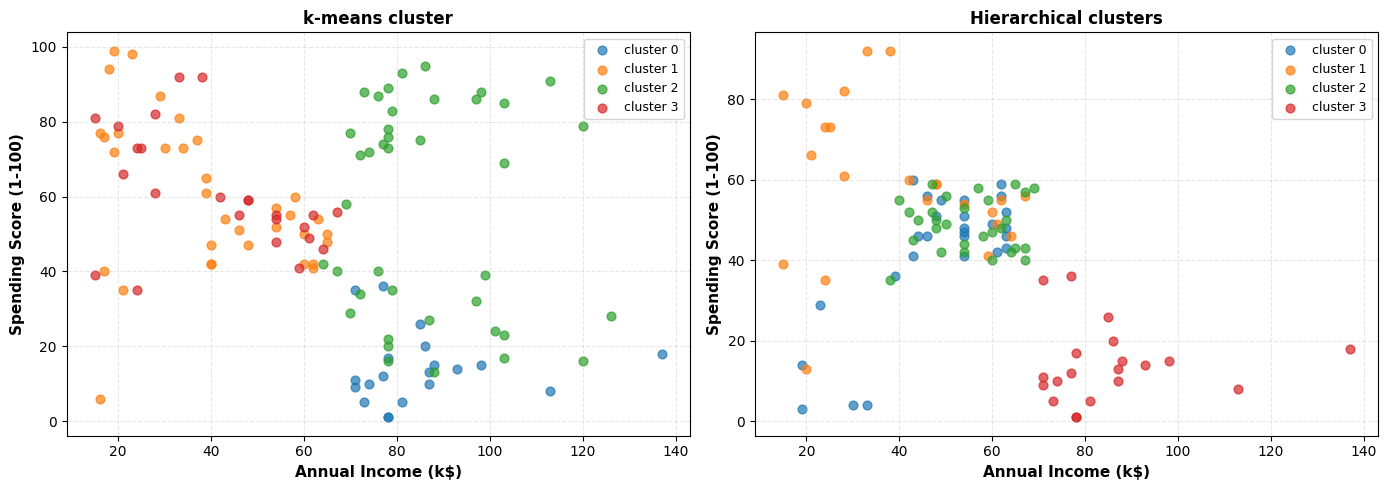

In [52]:
# apparently here i did a mistake since both models have different number of clusters, so i will plot them separately
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

for ax, col, title in zip(
    axes,
    ['cluster', 'hc_cluster'],
    ['k-means cluster', 'Hierarchical clusters']
):
    for c in range(4):
        mask = df[col] == c
        ax.scatter(df[mask]['Annual Income (k$)'], df[mask]['Spending Score (1-100)'], alpha=0.7, s = 40, label=f'cluster {c}')
    ax.set_xlabel('Annual Income (k$)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Spending Score (1-100)', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_10332\3654288484.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(df[mask]['Annual Income (k$)'], df[mask]['Spending Score (1-100)'],


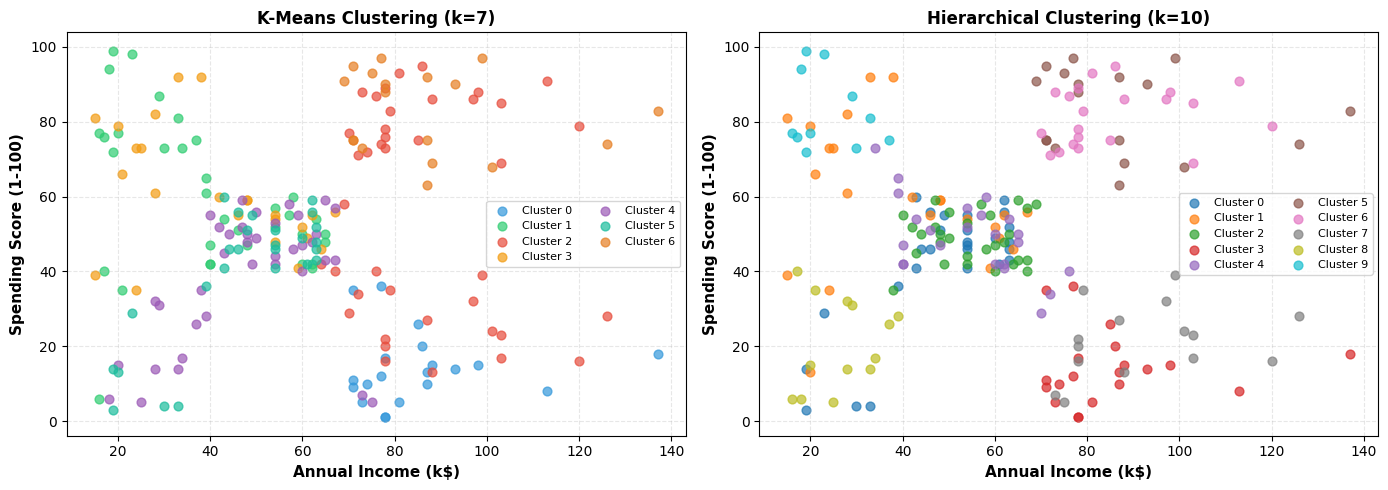

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define number of clusters for each method
n_kmeans = 7
n_hierarchical = 10

# Define colors for better visualization
colours_kmeans = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
colours_hierarchical = plt.cm.tab10(range(10))  # Auto-generate 10 colors

for idx, (ax, col, title, n_clusters, colours) in enumerate(zip(
    axes,
    ['cluster', 'hc_cluster'],
    ['K-Means Clustering (k=7)', 'Hierarchical Clustering (k=10)'],
    [n_kmeans, n_hierarchical],
    [colours_kmeans, colours_hierarchical]
)):
    for c in range(n_clusters):
        mask = df[col] == c
        ax.scatter(df[mask]['Annual Income (k$)'], df[mask]['Spending Score (1-100)'],
                   alpha=0.7, s=40, label=f'Cluster {c}', c=colours[c])

    # Add labels and title
    ax.set_xlabel('Annual Income (k$)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Spending Score (1-100)', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=8, ncol=2)  # 2 columns for readability with many clusters
    ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()